### Setup and data loading

In [52]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(font_scale=1.1)

from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [53]:
uploaded = files.upload()
df = pd.read_csv('heart.csv')
df.head(10)

Saving heart.csv to heart (1).csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [54]:
print("shape", df.shape)

shape (918, 12)


In [55]:
print("Info: ")
df.info()

Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [57]:
target_col = 'HeartDisease'
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [58]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [59]:
df[numeric_cols].agg(['min', 'max', 'mean', 'median']).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [60]:
for c in categorical_cols:
  print(c, df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


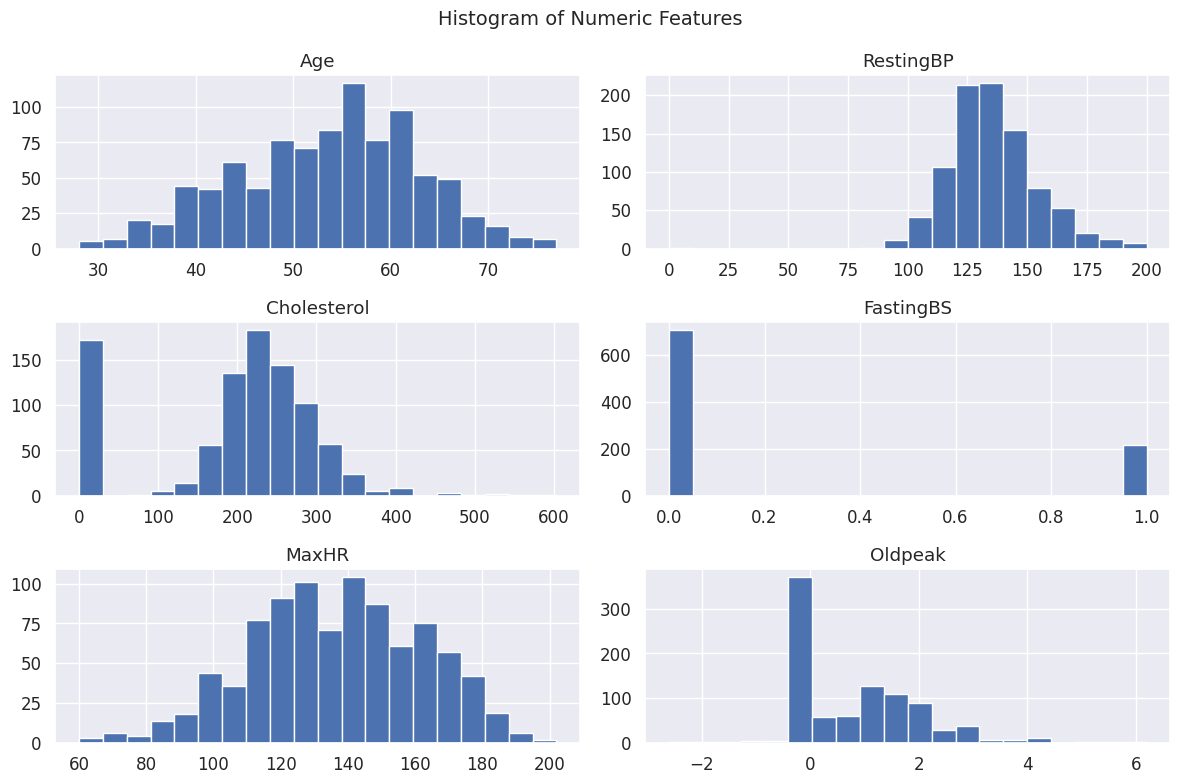

In [61]:
df[numeric_cols].hist(bins=20, figsize=(12,8))
plt.suptitle('Histogram of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

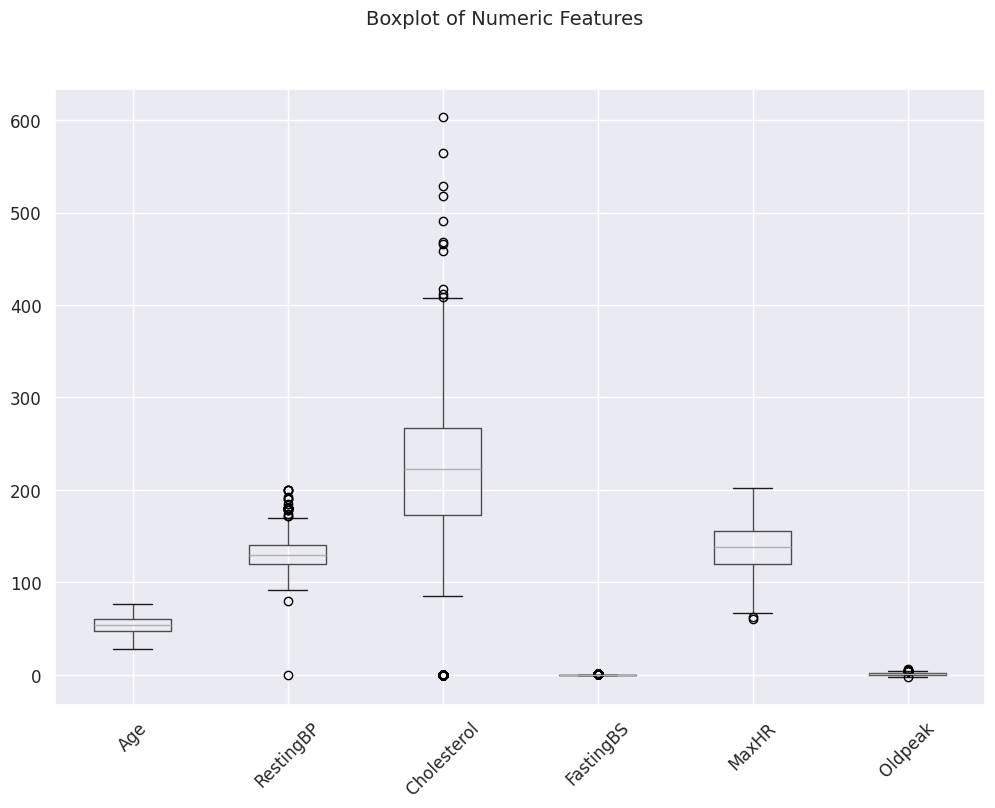

In [62]:
plt.figure(figsize=(12,8))
df[numeric_cols].boxplot()
plt.suptitle('Boxplot of Numeric Features', fontsize=14)
plt.xticks(rotation=45)
plt.show()

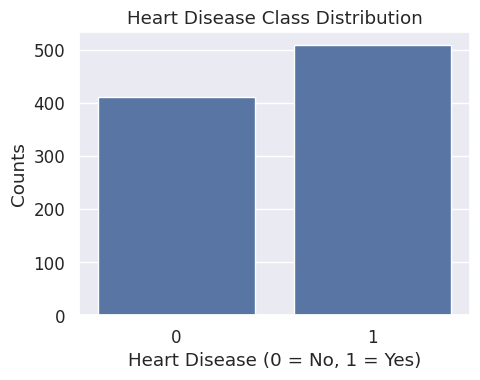

In [63]:
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

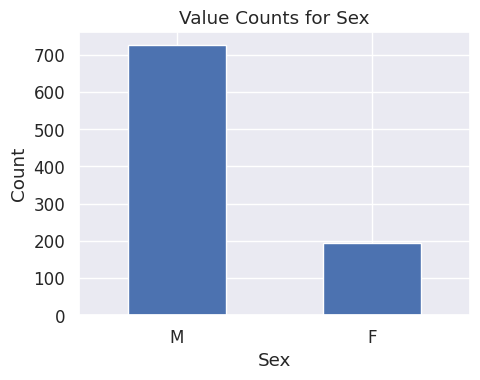

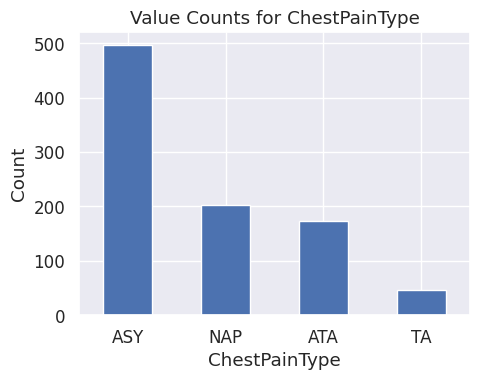

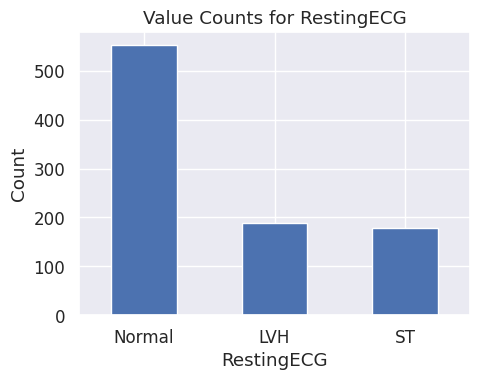

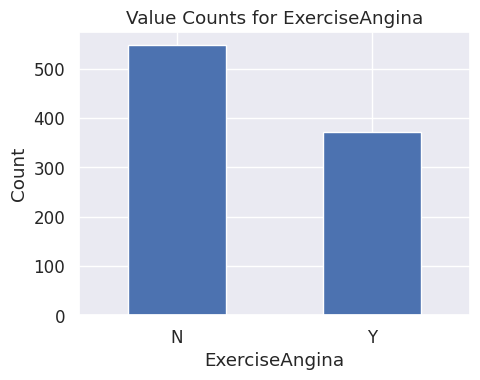

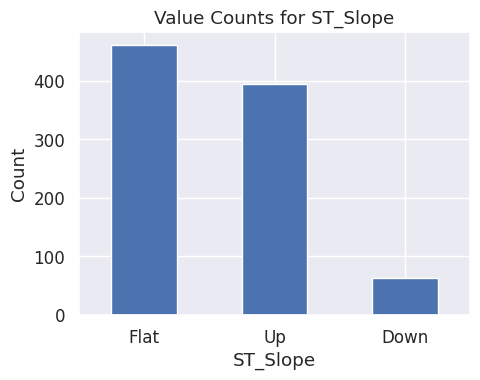

In [64]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind='bar')
  plt.title(f"Value Counts for {c}")
  plt.xticks(rotation=0)
  plt.ylabel('Count')
  plt.tight_layout()
  plt.show()

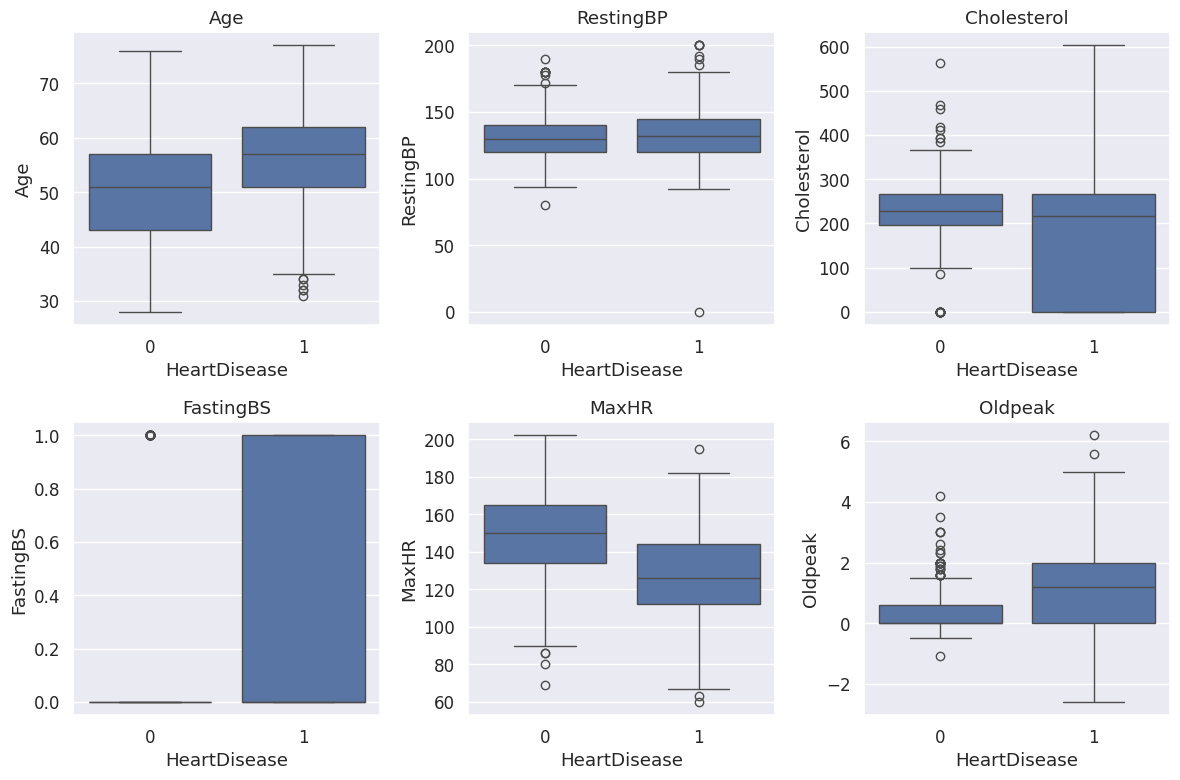

In [65]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols, 1):
  plt.subplot(2, 3, i)
  sns.boxplot(x=df[target_col], y=df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

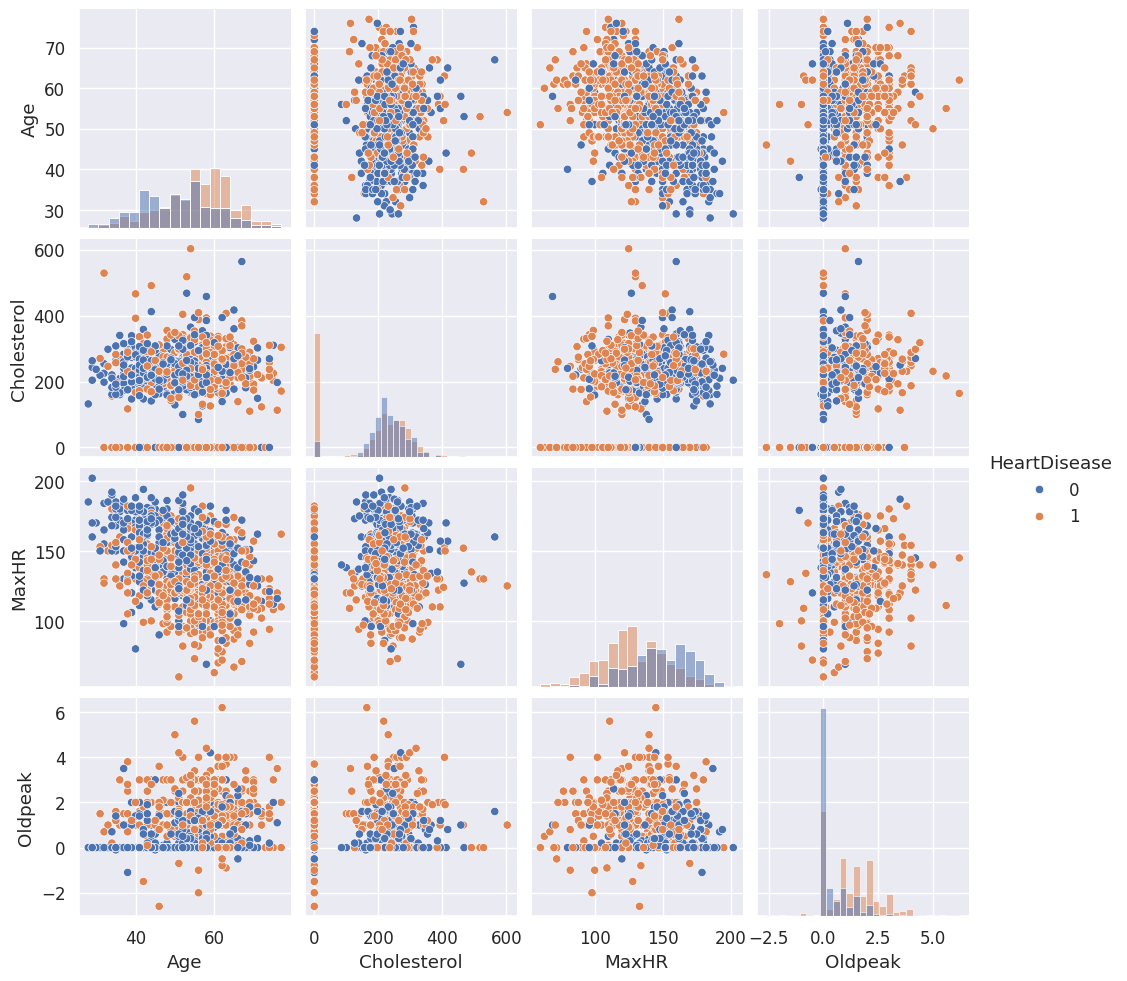

In [66]:
sns.pairplot(df[['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']], hue='HeartDisease', diag_kind='hist')
plt.show()

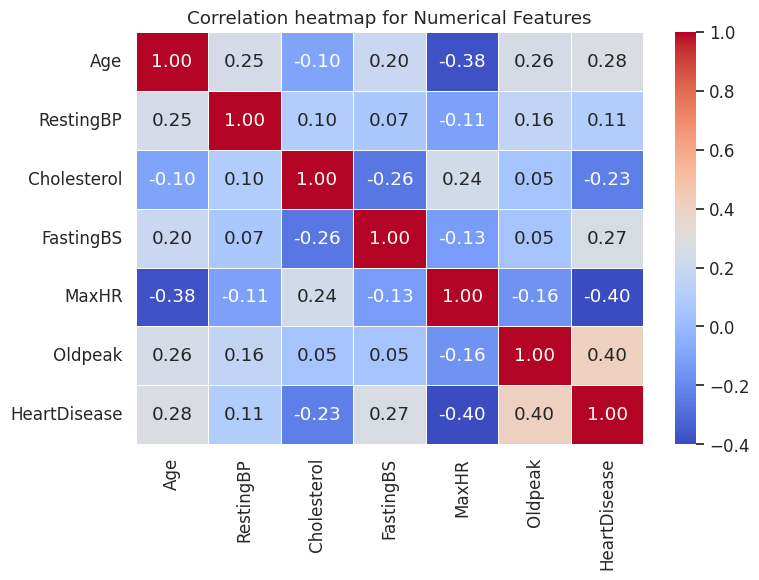

In [67]:
corr_matrix = df[numeric_cols + [target_col]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In [68]:
corr_matrix[target_col].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.107589
Cholesterol,-0.232741
MaxHR,-0.400421



Proportion of heart disease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


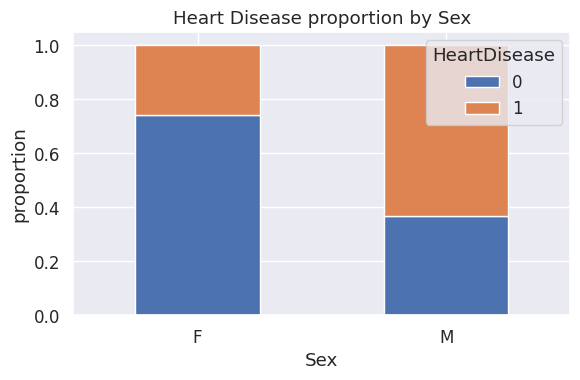


Proportion of heart disease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


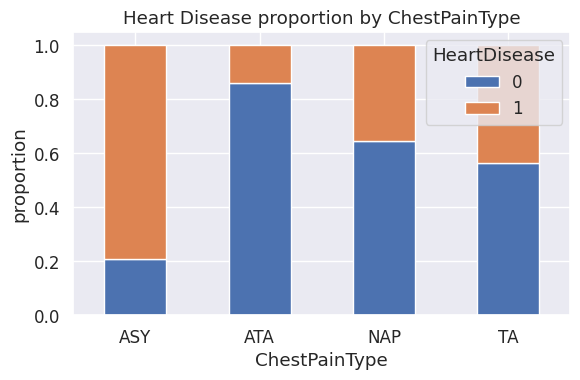


Proportion of heart disease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


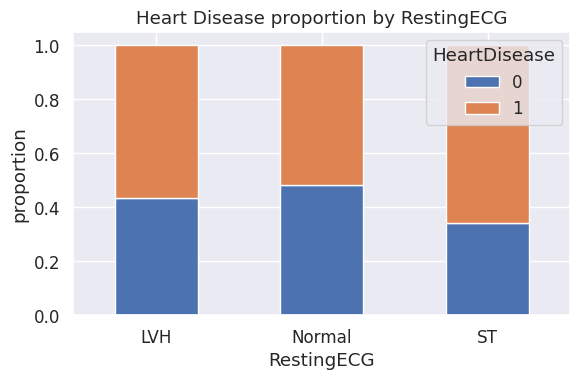


Proportion of heart disease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


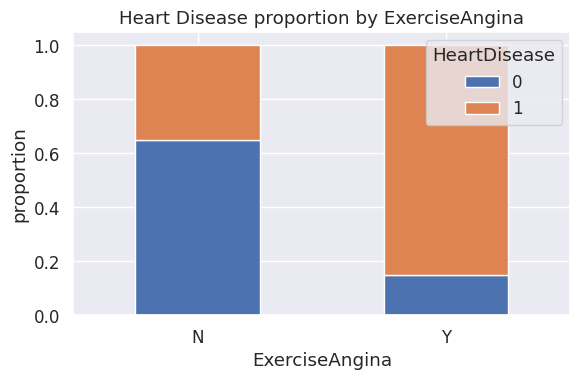


Proportion of heart disease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


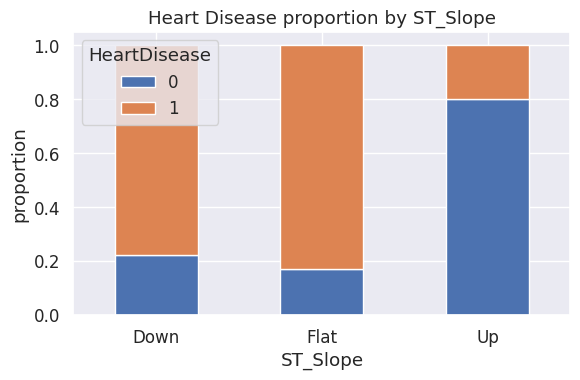

In [69]:
for c in categorical_cols:
  ct = pd.crosstab(df[c], df[target_col], normalize='index')
  print(f'\nProportion of heart disease within {c}')
  display(ct)

  ct.plot(kind='bar', stacked=True, figsize=(6,4))

  plt.title(f'Heart Disease proportion by {c}')
  plt.ylabel('proportion')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

In [70]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])

In [71]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [72]:
cat_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    dtype=int
)

df_encoded.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


In [73]:
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

scaler_sd = StandardScaler()
X_train_std = scaler_sd.fit_transform(X_train)
X_test_std = scaler_sd.transform(X_test)

X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)

In [74]:
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_train.columns, index=X_train.index)
X_test_mm_df = pd.DataFrame(X_test_mm, columns=X_test.columns, index=X_test.index)

In [75]:
# df_scaled = df_encoded.copy()
# df_scaled[numeric_cols] = scaler_sd.fit_transform(df[numeric_cols])
# df_encoded = df_scaled
# df_encoded.head()

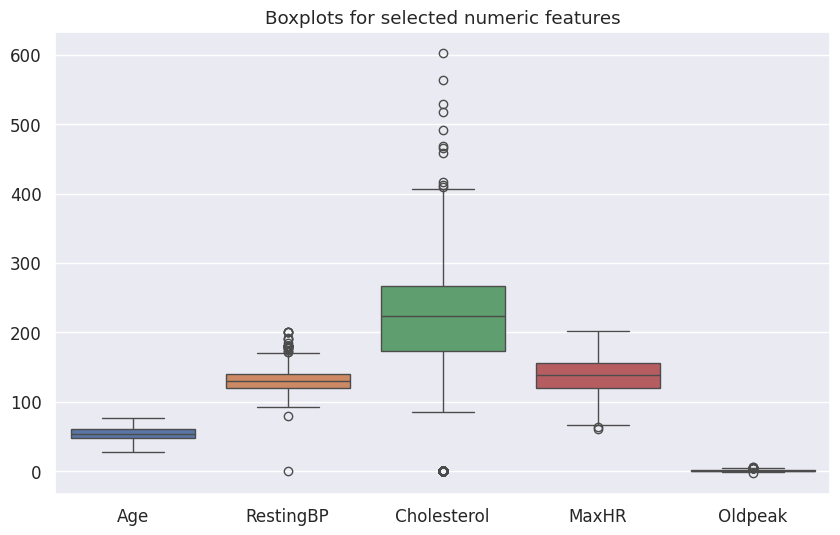

In [99]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_encoded[numeric_cols])
plt.title("Boxplots for selected numeric features")
plt.show()

In [77]:
col = 'Cholesterol'

Q1 = df_encoded[col].quantile(0.25)
Q3 = df_encoded[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df_encoded[(df_encoded[col] < lower) | (df_encoded[col] > upper)]
print(f"Numbers of outliers detected in {col}: {len(outliers)}")

Numbers of outliers detected in Cholesterol: 183


In [81]:
# 1. Remove outliers
df_no_outliers = df_encoded[(df_encoded[col] >= lower) & (df_encoded[col] <= upper)]
print(len(df_no_outliers))
# 2. Cap outliers (winsorization-like approach)
df_capped = df_encoded.copy()
df_capped[col] = df_capped[col].clip(lower, upper)
print(len(df_capped))
# 3. Log transformation --> Best
df_log = df_encoded.copy()
df_log[col + '_log'] = np.log(df_log[col] + 1)
df_log.head()

735
918


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Cholesterol_log
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1,5.669881
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0,5.198497
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1,5.648974
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0,5.370638
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1,5.278115


In [85]:
from sklearn.preprocessing import PolynomialFeatures

poly_cols = ['Age', 'MaxHR']
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df_encoded[poly_cols])
poly_features_names = poly.get_feature_names_out(poly_cols)

print(poly_features_names)
print(poly_features.shape)
print(poly_features)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)
[[   40.   172.  1600.  6880. 29584.]
 [   49.   156.  2401.  7644. 24336.]
 [   37.    98.  1369.  3626.  9604.]
 ...
 [   57.   115.  3249.  6555. 13225.]
 [   57.   174.  3249.  9918. 30276.]
 [   38.   173.  1444.  6574. 29929.]]


In [93]:
# Binning Age into categories
df_encoded['Age_bin'] = pd.cut(
    df_encoded['Age'],
    bins = [0, 30, 50, 70, 100],
    labels = ['Young', 'Middle', 'Middle Old', 'Old']
)

df_encoded[['Age', 'Age_bin']].head(10)

,Age,Age_bin
0,40,Middle
1,49,Middle
2,37,Middle
3,48,Middle
4,54,Middle Old
5,39,Middle
6,45,Middle
7,54,Middle Old
8,37,Middle
9,48,Middle


In [97]:
# Domain Driven risk categories for RestingBP and OldPeak

def bp_risk(bp):
  if bp < 120:
    return 'Normal'
  elif bp < 140:
    return 'Elevated'
  else:
    return "High"

def oldpeak_risk(op):
  if op == 0:
    return 'No Stress'
  elif op < 2:
    return "Moderate Stress"
  else:
    return "High Stress"

df_encoded['BP_risk'] = df_encoded['RestingBP'].apply(bp_risk)
df_encoded['OldPeak_risk'] = df['Oldpeak'].apply(oldpeak_risk)
df_encoded[['RestingBP', 'Oldpeak', 'BP_risk', 'OldPeak_risk']].head(10)

,RestingBP,Oldpeak,BP_risk,OldPeak_risk
0,140,0.0,High,No Stress
1,160,1.0,High,Moderate Stress
2,130,0.0,Elevated,No Stress
3,138,1.5,Elevated,Moderate Stress
4,150,0.0,High,No Stress
5,120,0.0,Elevated,No Stress
6,130,0.0,Elevated,No Stress
7,110,0.0,Normal,No Stress
8,140,1.5,High,Moderate Stress
9,120,0.0,Elevated,No Stress


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [102]:
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope"]

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])


cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first'))
])

prepocess = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

clf = Pipeline([
    ('prep', prepocess),
    ('model', LogisticRegression(max_iter=100))
])

In [106]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(X, y, test_size=.25, random_state=42)

In [108]:
clf.fit(X_train_pipe, y_train_pipe)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Sex', 'ExerciseAngina',
                                                   'ChestPainType',
                                                   'RestingECG',
                                                   'ST_Slope'])])),
                ('model', LogisticRegression())])

In [109]:
from sklearn.metrics import accuracy_score

y_pred_pipe = clf.predict(X_test_pipe)
acc = accuracy_score(y_test_pipe, y_pred_pipe)
print("Logistic Regression with prepocessing pipeline", acc)

Logistic Regression with prepocessing pipeline 0.8434782608695652
